# notebook_02: Veri Görselleştirme

Bu notebook, verilerdeki kalıpları, mevsimsel trendleri ve dağılımları grafikler yoluyla analiz etmek amacıyla hazırlanmıştır.

### Yapılan İşlemler:
1. 3 ilçenin Hesap Sınıfı dağılımlarının subplotlar ile yan yana gösterimi
2. Aylık ortalama tüketim trendlerinin çizgi grafiği ile gösterimi
3. Tahsilat yapılan şube ve ilçe dağılımlarının bar chart analizi
4. Fatura ödeme zamanlamasının pasta grafiği ile gösterimi
5. kWh tüketim dağılımının histogram ve box plot ile analizi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r'../data/elektrik_veri_hashed.xlsx'
xls = pd.ExcelFile(file_path)

# Tüm sayfaları orijinal isimleriyle DataFrame'lere yükleme
df_tahsilat = pd.read_excel(xls, sheet_name='Tahsilat')
df_tahsilat_1 = pd.read_excel(xls, sheet_name='Tahsilat 1')
df_tahakkuk = pd.read_excel(xls, sheet_name='Tahakkuk')        # Hamamözü
df_tahakkuk_1 = pd.read_excel(xls, sheet_name='Tahakkuk 1')    # Gümüşhacıköy
df_tahakkuk_2 = pd.read_excel(xls, sheet_name='Tahakkuk 2')    # Göynücek

# Birleştirilmiş genel veri seti
df_tahakkuk_all = pd.concat([df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2], ignore_index=True)

# Tarih dönüşümleri ve ay sütunları
df_tahakkuk['mali_yil_donem'] = pd.to_datetime(df_tahakkuk['mali_yil_donem'])
df_tahakkuk['ay'] = df_tahakkuk['mali_yil_donem'].dt.month

df_tahakkuk_1['mali_yil_donem'] = pd.to_datetime(df_tahakkuk_1['mali_yil_donem'])
df_tahakkuk_1['ay'] = df_tahakkuk_1['mali_yil_donem'].dt.month

df_tahakkuk_2['mali_yil_donem'] = pd.to_datetime(df_tahakkuk_2['mali_yil_donem'])
df_tahakkuk_2['ay'] = df_tahakkuk_2['mali_yil_donem'].dt.month

# Grafik stil ve Türkçe karakter ayarları
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

print("Notebook 02 için tüm veriler ve bağımlılıklar başarıyla yüklendi!")

Notebook 02 için tüm veriler ve bağımlılıklar başarıyla yüklendi!


C:\Users\ömer\AppData\Local\Temp\ipykernel_21416\1497173329.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data_counts.values, y=data_counts.index, ax=axes[idx], palette='viridis')
C:\Users\ömer\AppData\Local\Temp\ipykernel_21416\1497173329.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data_counts.values, y=data_counts.index, ax=axes[idx], palette='viridis')
C:\Users\ömer\AppData\Local\Temp\ipykernel_21416\1497173329.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data_counts.values, y=data_counts.index, ax=axes[idx],

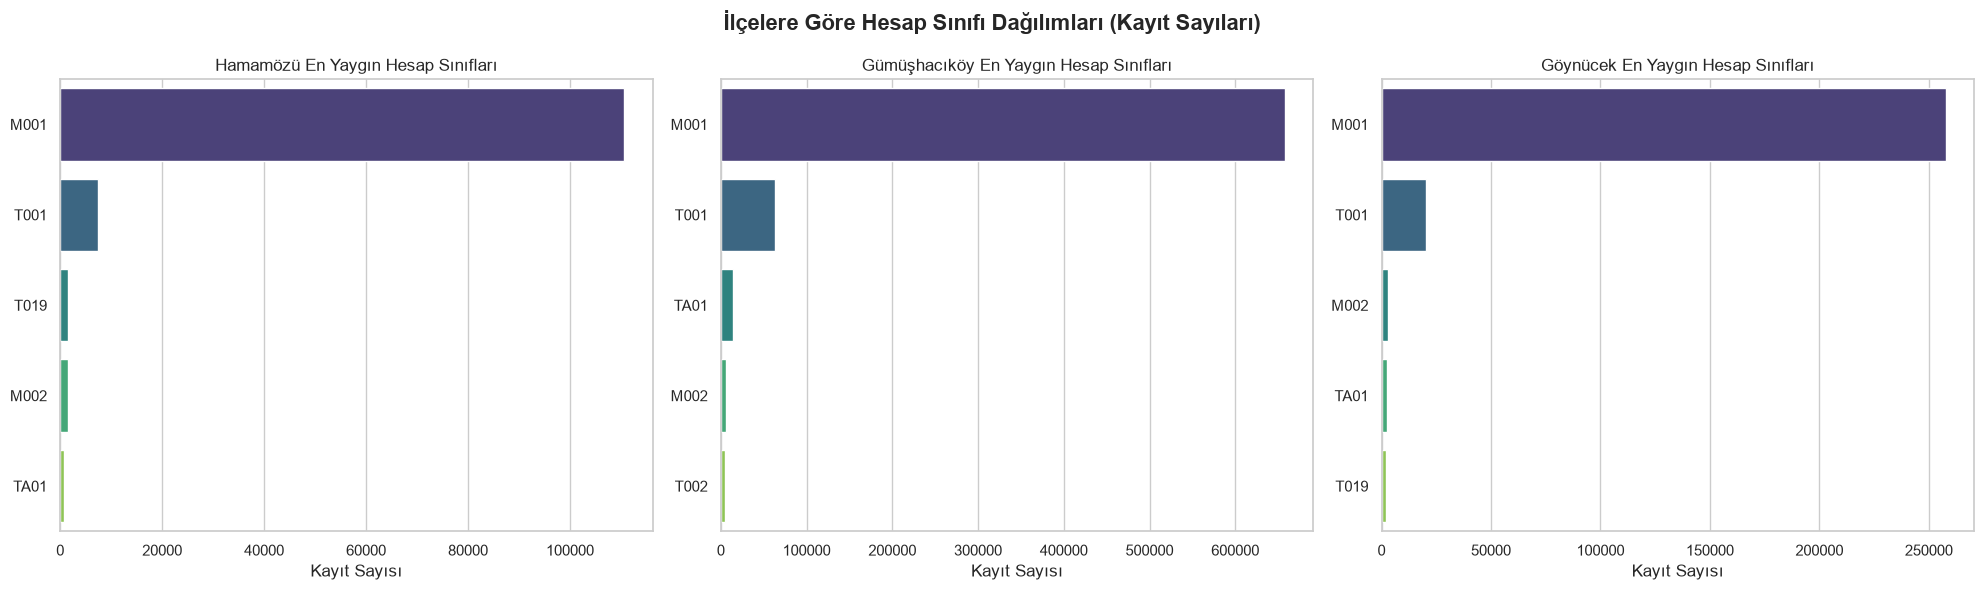

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafik stil ve Türkçe karakter ayarları
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
fig.suptitle('İlçelere Göre Hesap Sınıfı Dağılımları (Kayıt Sayıları)', fontsize=16, fontweight='bold')

ilceler = [
    ('Hamamözü', df_tahakkuk),
    ('Gümüşhacıköy', df_tahakkuk_1),
    ('Göynücek', df_tahakkuk_2)
]

for idx, (ilce_adi, df_ilce) in enumerate(ilceler):
    data_counts = df_ilce['hesap_sinifi'].value_counts().head(5)
    sns.barplot(x=data_counts.values, y=data_counts.index, ax=axes[idx], palette='viridis')
    axes[idx].set_title(f'{ilce_adi} En Yaygın Hesap Sınıfları')
    axes[idx].set_xlabel('Kayıt Sayısı')
    axes[idx].set_ylabel('')

plt.tight_layout()
plt.savefig('../outputs/figures/ilce_karsilastirma.png', dpi=300, bbox_inches='tight')
plt.show()

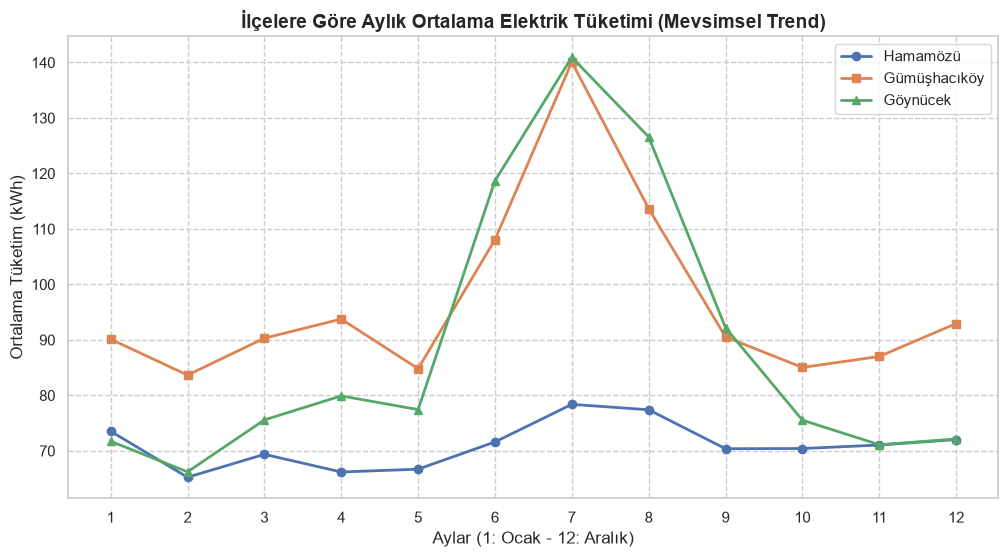

In [3]:
# Her dataframe için tarih dönüşümü
df_tahakkuk['mali_yil_donem'] = pd.to_datetime(df_tahakkuk['mali_yil_donem'])
df_tahakkuk['ay'] = df_tahakkuk['mali_yil_donem'].dt.month

df_tahakkuk_1['mali_yil_donem'] = pd.to_datetime(df_tahakkuk_1['mali_yil_donem'])
df_tahakkuk_1['ay'] = df_tahakkuk_1['mali_yil_donem'].dt.month

df_tahakkuk_2['mali_yil_donem'] = pd.to_datetime(df_tahakkuk_2['mali_yil_donem'])
df_tahakkuk_2['ay'] = df_tahakkuk_2['mali_yil_donem'].dt.month

# Aylık ortalama kwh değerleri
hamamozu_monthly = df_tahakkuk.groupby('ay')['kwh'].mean()
gumushacikoy_monthly = df_tahakkuk_1.groupby('ay')['kwh'].mean()
goynucek_monthly = df_tahakkuk_2.groupby('ay')['kwh'].mean()

# Çizgi grafiği
plt.figure(figsize=(12, 6))
plt.plot(hamamozu_monthly.index, hamamozu_monthly.values, marker='o', label='Hamamözü', linewidth=2)
plt.plot(gumushacikoy_monthly.index, gumushacikoy_monthly.values, marker='s', label='Gümüşhacıköy', linewidth=2)
plt.plot(goynucek_monthly.index, goynucek_monthly.values, marker='^', label='Göynücek', linewidth=2)

plt.title('İlçelere Göre Aylık Ortalama Elektrik Tüketimi (Mevsimsel Trend)', fontsize=14, fontweight='bold')
plt.xlabel('Aylar (1: Ocak - 12: Aralık)')
plt.ylabel('Ortalama Tüketim (kWh)')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True, linestyle='--')
plt.savefig('../outputs/figures/mevsimsel_tuketim.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\ömer\AppData\Local\Temp\ipykernel_21416\2299603055.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_tahsilat, x='İlçe', ax=axes[0], palette='muted', order=df_tahsilat['İlçe'].value_counts().index)
C:\Users\ömer\AppData\Local\Temp\ipykernel_21416\2299603055.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_subeler.values, y=top_subeler.index, ax=axes[1], palette='magma')


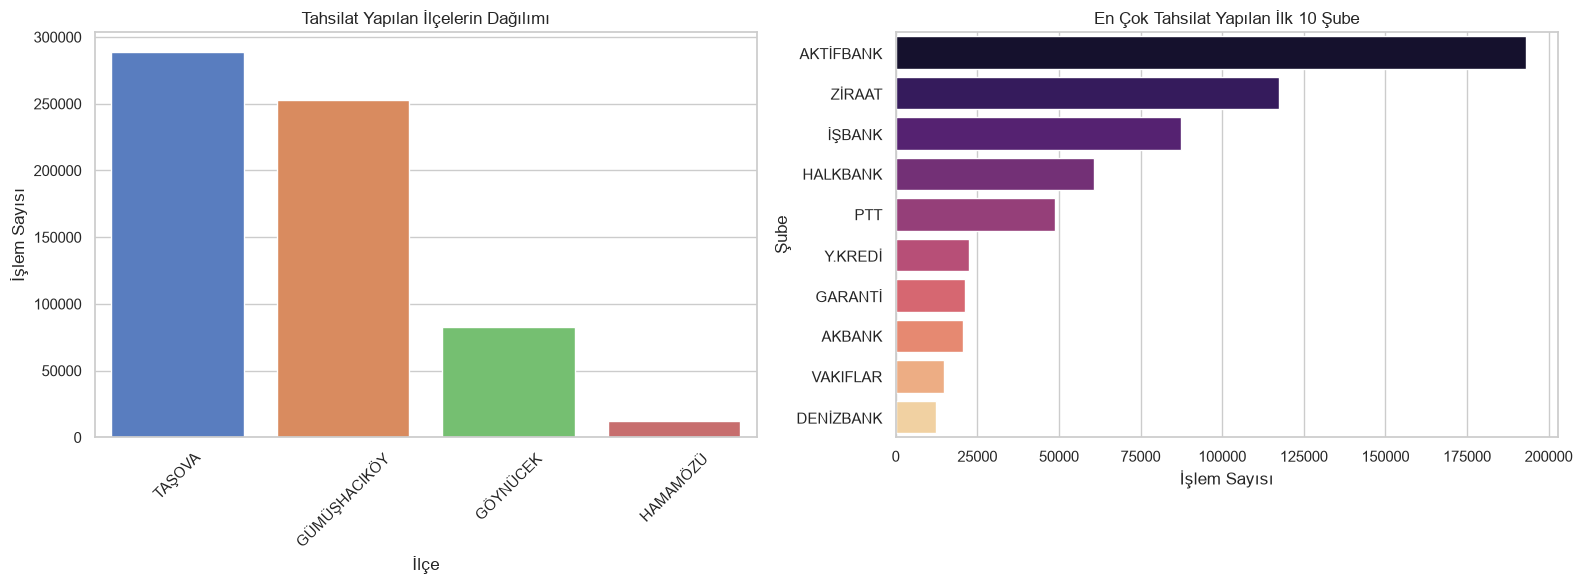

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# İlçe dağılımı
sns.countplot(data=df_tahsilat, x='İlçe', ax=axes[0], palette='muted', order=df_tahsilat['İlçe'].value_counts().index)
axes[0].set_title('Tahsilat Yapılan İlçelerin Dağılımı')
axes[0].set_xlabel('İlçe')
axes[0].set_ylabel('İşlem Sayısı')
axes[0].tick_params(axis='x', rotation=45)

# Şube dağılımı (İlk 10 şube)
top_subeler = df_tahsilat['Şube'].value_counts().head(10)
sns.barplot(x=top_subeler.values, y=top_subeler.index, ax=axes[1], palette='magma')
axes[1].set_title('En Çok Tahsilat Yapılan İlk 10 Şube')
axes[1].set_xlabel('İşlem Sayısı')

plt.tight_layout()
plt.savefig('../outputs/figures/tahsilat_sube_dagilimi.png', dpi=300, bbox_inches='tight')
plt.show()

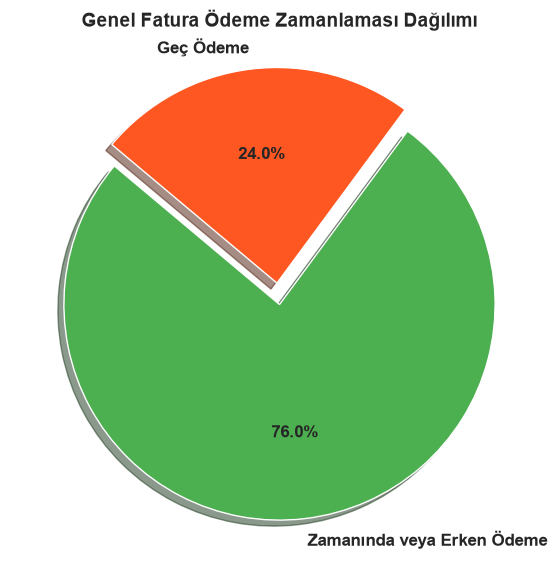

In [5]:
# Referans: Zamanında/Erken: 789,588 kayıt, Geç: 249,487 kayıt
zamaninda_sayisi = 789588
gec_sayisi = 249487

labels = ['Zamanında veya Erken Ödeme', 'Geç Ödeme']
sizes = [zamaninda_sayisi, gec_sayisi]
colors = ['#4CAF50', '#FF5722']
explode = (0, 0.1)  # Geç ödemeyi biraz dışarı çıkaralım vurgu için

plt.figure(figsize=(7, 7))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140, textprops={'fontsize': 12, 'weight': 'bold'})
plt.title('Genel Fatura Ödeme Zamanlaması Dağılımı', fontsize=14, fontweight='bold')
plt.savefig('../outputs/figures/odeme_zamanlamasi_pasta.png', dpi=300, bbox_inches='tight')
plt.show()

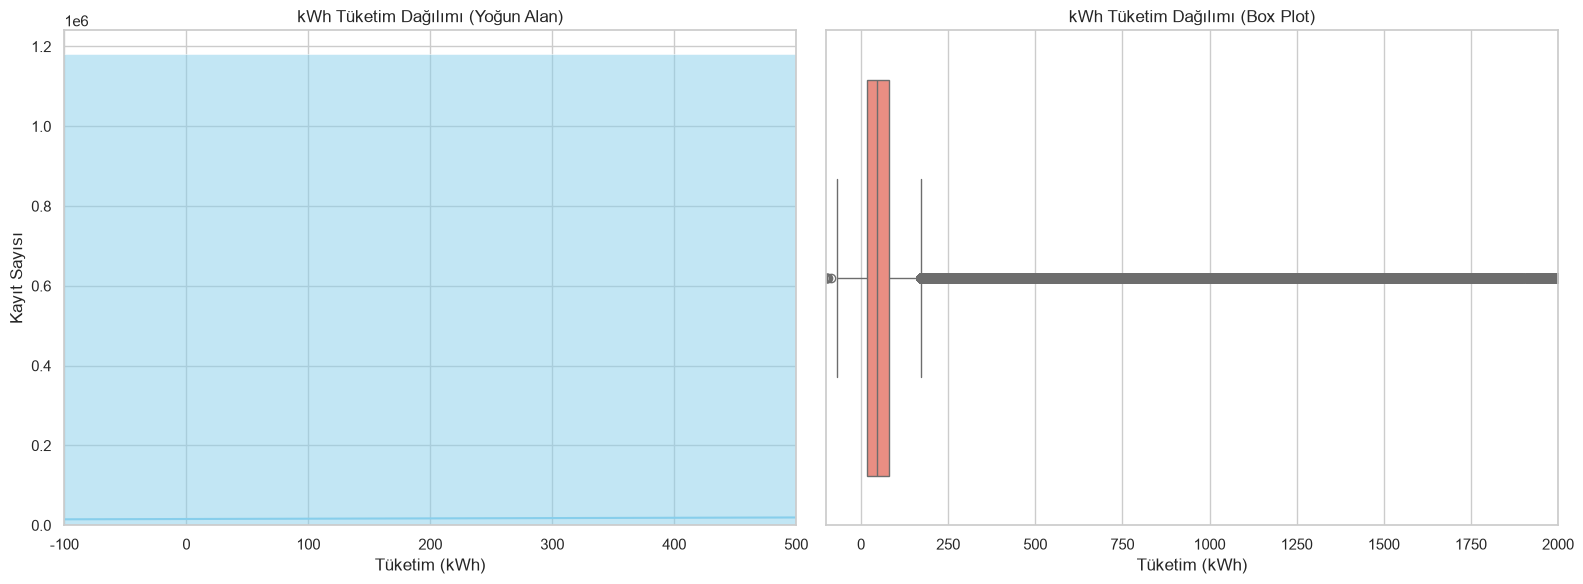

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram Güncelleme 
sns.histplot(data=df_tahakkuk_all, x='kwh', bins=100, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('kWh Tüketim Dağılımı (Yoğun Alan)')
axes[0].set_xlabel('Tüketim (kWh)')
axes[0].set_ylabel('Kayıt Sayısı')
axes[0].set_xlim(-100, 500)  # Çoğunluğun olduğu yere zoom yapalım

# Box Plot 
sns.boxplot(data=df_tahakkuk_all, x='kwh', ax=axes[1], color='salmon')
axes[1].set_title('kWh Tüketim Dağılımı (Box Plot)')
axes[1].set_xlabel('Tüketim (kWh)')
axes[1].set_xlim(-100, 2000) 

plt.tight_layout()
plt.savefig('../outputs/figures/kwh_tuketim_dagilimi.png', dpi=300, bbox_inches='tight')
plt.show()